In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from experiment_utils import run_one_experiment, save_result, run, MLPClassifier, save_result_v1
import torch
import torch.nn as nn

In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data.drop(columns='Unnamed: 0', inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  1239 non-null   str    
 1   home_team             1239 non-null   str    
 2   away_team             1239 non-null   str    
 3   home_score            1239 non-null   float64
 4   away_score            1239 non-null   float64
 5   tournament            1239 non-null   str    
 6   city                  1239 non-null   str    
 7   country               1239 non-null   str    
 8   neutral               1239 non-null   int64  
 9   year                  1239 non-null   int64  
 10  is_world_cup          1239 non-null   int64  
 11  is_qualifier          1239 non-null   int64  
 12  match_id              1239 non-null   int64  
 13  home_rank_date_used   1239 non-null   str    
 14  home_rank             1239 non-null   float64
 15  home_previous_rank    1239 non-n

In [3]:
X = data[['rank_advantage', 'elo_advantage']]
y = data['result']

In [4]:
label_mapping = {
    -1:0,
    0:1,
    1:2
}

y_enc = y.map(label_mapping)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    random_state=42,
    shuffle = False
)

In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [7]:
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [10]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8018 | val loss = 0.7662 | val acc = 0.6432
Epoch 100/1000 | train loss = 0.7910 | val loss = 0.7670 | val acc = 0.6583
Epoch 150/1000 | train loss = 0.7876 | val loss = 0.7738 | val acc = 0.6482
Epoch 200/1000 | train loss = 0.7709 | val loss = 0.7783 | val acc = 0.6482
Epoch 250/1000 | train loss = 0.7725 | val loss = 0.7863 | val acc = 0.6482
Epoch 300/1000 | train loss = 0.7772 | val loss = 0.7900 | val acc = 0.6533
Epoch 350/1000 | train loss = 0.7771 | val loss = 0.7920 | val acc = 0.6583
Epoch 400/1000 | train loss = 0.7661 | val loss = 0.8023 | val acc = 0.6683
Epoch 450/1000 | train loss = 0.7701 | val loss = 0.8017 | val acc = 0.6734
Epoch 500/1000 | train loss = 0.7742 | val loss = 0.8029 | val acc = 0.6734
Epoch 550/1000 | train loss = 0.7779 | val loss = 0.8057 | val acc = 0.6734
Epoch 600/1000 | train loss = 0.7662 | val loss = 0.8076 | val acc = 0.6633
Epoch 650/1000 | train loss = 0.7726 | val loss = 0.8131 | val acc = 0.6683
Epoch 700/100

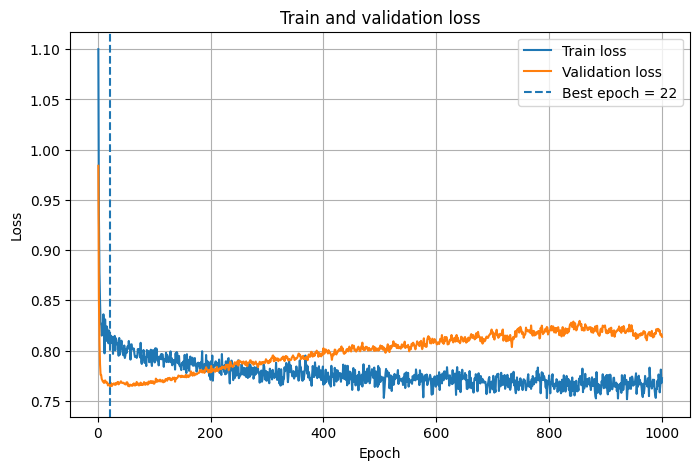

0.5725806451612904

In [11]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [12]:
best_num_epochs = 22

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5726 | Precision: 0.5475 | Recall: 0.5006 | Specificity: 0.7574 | F1: 0.4350

Run 2/10
Accuracy: 0.5605 | Precision: 0.4533 | Recall: 0.4936 | Specificity: 0.7542 | F1: 0.4385

Run 3/10
Accuracy: 0.5685 | Precision: 0.4898 | Recall: 0.4955 | Specificity: 0.7555 | F1: 0.4313

Run 4/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 5/10
Accuracy: 0.5726 | Precision: 0.3802 | Recall: 0.5008 | Specificity: 0.7574 | F1: 0.4278

Run 6/10
Accuracy: 0.5685 | Precision: 0.3752 | Recall: 0.4979 | Specificity: 0.7562 | F1: 0.4243

Run 7/10
Accuracy: 0.5685 | Precision: 0.3794 | Recall: 0.4979 | Specificity: 0.7555 | F1: 0.4263

Run 8/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 9/10
Accuracy: 0.5726 | Precision: 0.3802 | Recall: 0.5008 | Specificity: 0.7574 | F1: 0.4278

Run 10/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Summary o

In [13]:
save_result(
    experiment_name="Experiment_1-6_FIFA_and_ELO_ranks_diff",
    summary=summary
)

save_result_v1(
    experiment_name="Experiment_1-6_FIFA_and_ELO_ranks_diff",
    summary=summary
)


Saved result for Experiment_1-6_FIFA_and_ELO_ranks_diff
File: ../results/experiment_summary_final.csv

Saved result for Experiment_1-6_FIFA_and_ELO_ranks_diff
File: ../results/experiment_summary_v1.csv
